<a href="https://colab.research.google.com/github/sairaawahid/Data-Science-in-Python-Data-Prep-and-EDA/blob/main/Exploratory%20Data%20Analysis/Exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis
**Methods/functions practiced for exploratory data analysis:**
1.  `loc[]` with logical conditions
2.  `sort_values()`
3.  Chain on multiple functions
4.  `plot.bar()`, `plot.barh()`, `plot.line()`
5.  `isin()`
6.  `iloc[]`


**Datasets:**
1.  groceries_with_new_columns.pkl

## 1. Filtering

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

In [3]:
groceries = pd.read_pickle('/content/drive/MyDrive/Data Science in Pyhton by Maven Analytics/1. Data Prep & EDA/Data/groceries_with_new_columns.pkl')
groceries.head()

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
0,P100010,100010,Produce,Fruit,Apple,False,1.50,349,7.19,,2023-06-12 15:35:00,15:35:00,2023-06-15,Thursday
1,P100011,100011,Produce,Fruit,Banana,False,0.40,500,10.29,,2023-06-12 18:30:00,18:30:00,2023-06-15,Thursday
2,P100012,100012,Produce,Fruit,Grapes,False,4.00,200,4.12,,2023-06-12 17:22:00,17:22:00,2023-06-15,Thursday
3,P100013,100013,Produce,Fruit,Grapefruit,False,0.99,50,1.03,,2023-06-12 16:29:00,16:29:00,2023-06-15,Thursday
4,P100014,100014,Produce,Fruit,Organic Strawberries,True,3.99,148,3.05,,2023-06-12 18:10:00,18:10:00,2023-06-15,Thursday


In [4]:
# Only filter on low inventory rows
groceries[groceries['Low Inventory'] == 'Low inventory']

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
15,P100025,100025,Produce,Dairy,Milk (Soy),False,4.49,32,0.66,Low inventory,2023-06-13 08:37:00,08:37:00,2023-06-17,Saturday
17,P100027,100027,Pantry,Snacks,Apple Sauce - organic,True,1.50,27,0.56,Low inventory,2023-06-10 12:02:00,12:02:00,2023-06-24,Saturday
20,P100030,100030,Pantry,Snacks,Raisins,False,2.99,5,0.10,Low inventory,2023-06-10 12:38:00,12:38:00,2023-06-24,Saturday


In [5]:
# Filter on both rows and column using .loc[]
# Create a list to filter more than 1 column
groceries.loc[groceries['Low Inventory'] == 'Low inventory', ['Price_Dollars', 'Inventory']]

,Price_Dollars,Inventory
15,4.49,32
17,1.50,27
20,2.99,5


In [6]:
# Filter on the snacks subcategory
groceries[groceries.Subcategory == 'Snacks']

# No output??

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW


In [7]:
# Check one value
groceries.Subcategory[0]

' Fruit'

In [8]:
# Strip the blank space then filter
groceries.Subcategory = groceries.Subcategory.str.strip()

In [9]:
# Filter on the snacks subcategory
groceries[groceries.Subcategory == 'Snacks']

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
17,P100027,100027,Pantry,Snacks,Apple Sauce - organic,True,1.50,27,0.56,Low inventory,2023-06-10 12:02:00,12:02:00,2023-06-24,Saturday
18,P100028,100028,Pantry,Snacks,Chips,False,2.50,365,7.51,,2023-06-10 12:12:00,12:12:00,2023-06-24,Saturday
19,P100029,100029,Pantry,Snacks,Cookies (Oatmeal),False,5.39,340,7.00,,2023-06-10 12:24:00,12:24:00,2023-06-24,Saturday
20,P100030,100030,Pantry,Snacks,Raisins,False,2.99,5,0.10,Low inventory,2023-06-10 12:38:00,12:38:00,2023-06-24,Saturday


In [10]:
# Filter on low inventory snacks
mask = (groceries['Low Inventory'] == 'Low inventory') & (groceries.Subcategory == 'Snacks')
groceries[mask]

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
17,P100027,100027,Pantry,Snacks,Apple Sauce - organic,True,1.50,27,0.56,Low inventory,2023-06-10 12:02:00,12:02:00,2023-06-24,Saturday
20,P100030,100030,Pantry,Snacks,Raisins,False,2.99,5,0.10,Low inventory,2023-06-10 12:38:00,12:38:00,2023-06-24,Saturday


In [11]:
# Filter rows and columns
groceries.loc[mask, ['Subcategory', 'Item', 'Inventory']]

,Subcategory,Item,Inventory
17,Snacks,Apple Sauce - organic,27
20,Snacks,Raisins,5


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 2. Sorting

In [12]:
# Sort by price
groceries.sort_values('Price_Dollars')

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
1,P100011,100011,Produce,Fruit,Banana,False,0.40,500,10.29,,2023-06-12 18:30:00,18:30:00,2023-06-15,Thursday
3,P100013,100013,Produce,Fruit,Grapefruit,False,0.99,50,1.03,,2023-06-12 16:29:00,16:29:00,2023-06-15,Thursday
9,P100019,100019,Produce,Vegetable,Cucumber,False,0.99,230,4.74,,2023-06-12 17:47:00,17:47:00,2023-06-15,Thursday
16,P100026,100026,Produce,Dairy,Yogurt,False,1.00,432,8.89,,2023-06-13 08:41:00,08:41:00,2023-06-17,Saturday
17,P100027,100027,Pantry,Snacks,Apple Sauce - organic,True,1.50,27,0.56,Low inventory,2023-06-10 12:02:00,12:02:00,2023-06-24,Saturday
0,P100010,100010,Produce,Fruit,Apple,False,1.50,349,7.19,,2023-06-12 15:35:00,15:35:00,2023-06-15,Thursday
6,P100016,100016,Produce,Vegetable,Cabbage,False,1.78,78,1.61,,2023-06-12 19:25:00,19:25:00,2023-06-15,Thursday
8,P100018,100018,Produce,Vegetable,Celery,False,1.99,50,1.03,,2023-06-12 16:42:00,16:42:00,2023-06-15,Thursday
7,P100017,100017,Produce,Vegetable,Carrots,False,2.00,200,4.12,,2023-06-12 18:05:00,18:05:00,2023-06-15,Thursday
18,P100028,100028,Pantry,Snacks,Chips,False,2.50,365,7.51,,2023-06-10 12:12:00,12:12:00,2023-06-24,Saturday


In [13]:
# Sort by price in descening order
groceries.sort_values('Price_Dollars', ascending=False)

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
23,P100033,100033,Frozen,Frozen Fruit,Frozen Blueberries,False,10.99,162,3.34,,2023-05-28 22:14:00,22:14:00,2023-06-28,Wednesday
11,P100021,100021,Produce,Meat,Chicken (Organic),True,10.49,284,5.85,,2023-06-13 07:20:00,07:20:00,2023-06-17,Saturday
10,P100020,100020,Produce,Meat,Beef,False,8.99,145,2.99,,2023-06-13 07:00:00,07:00:00,2023-06-17,Saturday
12,P100022,100022,Produce,Meat,Turkey,False,7.99,188,3.87,,2023-06-13 07:32:00,07:32:00,2023-06-17,Saturday
24,P100034,100034,Frozen,Frozen Fruit,Frozen Pineapple,False,7.96,178,3.66,,2023-05-28 22:11:00,22:11:00,2023-06-28,Wednesday
21,P100031,100031,Frozen,Frozen Snacks,Chicken Nuggets,False,6.99,85,1.75,,2023-05-28 22:02:00,22:02:00,2023-06-28,Wednesday
5,P100015,100015,Produce,Fruit,Watermelon,False,5.99,99,2.04,,2023-06-12 19:15:00,19:15:00,2023-06-15,Thursday
19,P100029,100029,Pantry,Snacks,Cookies (Oatmeal),False,5.39,340,7.00,,2023-06-10 12:24:00,12:24:00,2023-06-24,Saturday
22,P100032,100032,Frozen,Frozen Snacks,Spinach Dip,False,4.96,76,1.56,,2023-05-28 22:05:00,22:05:00,2023-06-28,Wednesday
15,P100025,100025,Produce,Dairy,Milk (Soy),False,4.49,32,0.66,Low inventory,2023-06-13 08:37:00,08:37:00,2023-06-17,Saturday


In [14]:
# Sort on multiple columns; subcategory by price
groceries.sort_values(['Subcategory', 'Price_Dollars']).head(10)

"""
First colmn passed will be sorted first, then second and so on
"""

'\nFirst colmn passed will be sorted first, then second and so on\n'

In [15]:
# Chain on sort_values
groceries[groceries['Low Inventory'] == 'Low inventory'].sort_values('Price_Dollars')

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
17,P100027,100027,Pantry,Snacks,Apple Sauce - organic,True,1.50,27,0.56,Low inventory,2023-06-10 12:02:00,12:02:00,2023-06-24,Saturday
20,P100030,100030,Pantry,Snacks,Raisins,False,2.99,5,0.10,Low inventory,2023-06-10 12:38:00,12:38:00,2023-06-24,Saturday
15,P100025,100025,Produce,Dairy,Milk (Soy),False,4.49,32,0.66,Low inventory,2023-06-13 08:37:00,08:37:00,2023-06-17,Saturday


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 3. Group By

In [16]:
# Group by category and show total inventory
groceries.groupby('Category')['Inventory'].sum()

,Inventory
Category,
Frozen,501
Pantry,737
Produce,3619


In [17]:
# Group by category and unique items
groceries.groupby('Category')['Inventory'].count()

,Inventory
Category,
Frozen,4
Pantry,4
Produce,17


In [18]:
# Group by category and subcategory and unique items
groceries.groupby(['Category', 'Subcategory'])['Inventory'].count().reset_index()

,Category,Subcategory,Inventory
0,Frozen,Frozen Fruit,2
1,Frozen,Frozen Snacks,2
2,Pantry,Snacks,4
3,Produce,Dairy,4
4,Produce,Fruit,6
5,Produce,Meat,3
6,Produce,Vegetable,4


In [19]:
# Group by category and subcategory, show total inventory and unique items
(groceries.groupby(['Category', 'Subcategory'])['Inventory']
          .agg(['sum', 'count'])
          .reset_index())

,Category,Subcategory,sum,count
0,Frozen,Frozen Fruit,340,2
1,Frozen,Frozen Snacks,161,2
2,Pantry,Snacks,737,4
3,Produce,Dairy,1098,4
4,Produce,Fruit,1346,6
5,Produce,Meat,617,3
6,Produce,Vegetable,558,4


In [20]:
# Group by category and show max priced item
groceries.groupby('Category')['Price_Dollars'].max().reset_index()

,Category,Price_Dollars
0,Frozen,10.99
1,Pantry,5.39
2,Produce,10.49


In [21]:
# Group by category and show max priced item in each category --- THIS IS INCORRECT!
groceries.groupby('Category')[['Item', 'Price_Dollars']].max().reset_index()

"""
This will not return most expensive item within each category
because .max() is being applied to 'Item' and 'Price_Dollars' separately
"""

"\nThis will not return most expensive item within each category\nbecause .max() is being applied to 'Item' and 'Price_Dollars' separately\n"

In [22]:
# THIS IS INCORRECT!
(groceries[['Category', 'Item', 'Price_Dollars']]
        .sort_values('Price_Dollars', ascending=False)
        .groupby('Category')
        .head(1))

,Category,Item,Price_Dollars
23,Frozen,Frozen Blueberries,10.99
11,Produce,Chicken (Organic),10.49
19,Pantry,Cookies (Oatmeal),5.39


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 4. Pandas Plots

### a. Bar Chart

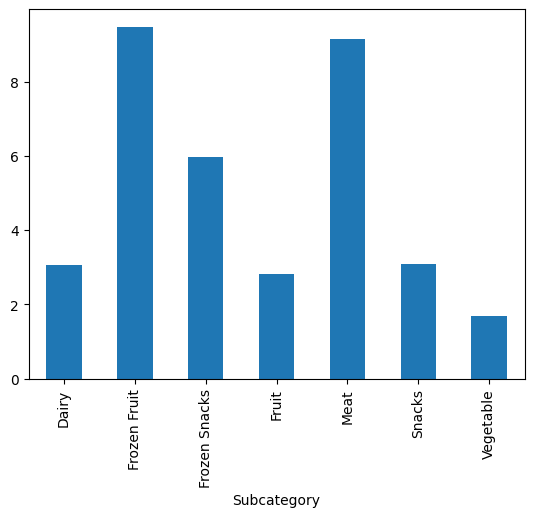

In [24]:
# Create a bar chart to show average price of each subcategory
groceries.groupby('Subcategory')['Price_Dollars'].mean().plot.bar();

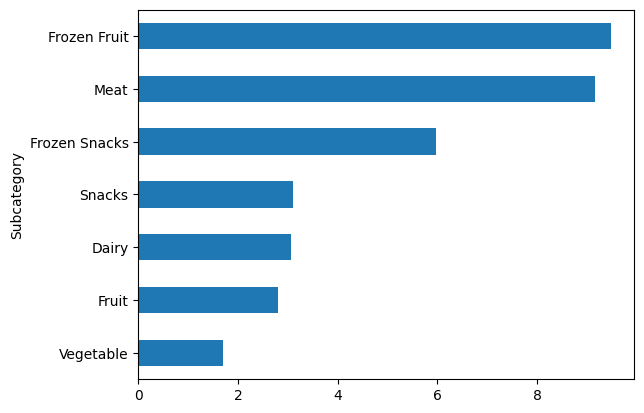

In [27]:
# Create a horizontal bar chart + sort values for above
groceries.groupby('Subcategory')['Price_Dollars'].mean().sort_values().plot.barh();

### b. Line Graph

In [28]:
happiness = pd.read_csv('/content/drive/MyDrive/Data Science in Pyhton by Maven Analytics/1. Data Prep & EDA/Data/happiness_survey_data.csv')
happiness.head()

,country_name,year,happiness_score,social_support,freedom_to_make_life_choices,healthy_life_expectancy_at_birth
0,Afghanistan,2008,3.723590,0.450662,0.718114,50.500000
1,Afghanistan,2009,4.401778,0.552308,0.678896,50.799999
2,Afghanistan,2010,4.758381,0.539075,0.600127,51.099998
3,Afghanistan,2011,3.831719,0.521104,0.495901,51.400002
4,Afghanistan,2012,3.782938,0.520637,0.530935,51.700001


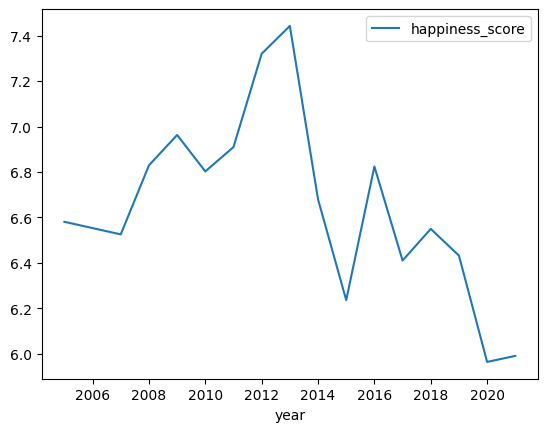

In [31]:
# Create a line chart for Mexico's happiness scores
happiness[happiness.country_name == 'Mexico'].iloc[:, 1:3].plot.line(x='year', y='happiness_score');

In [34]:
# Subset and pivot data to create multiple plots
(happiness[happiness.country_name
            .isin(['Canada', 'Mexico', 'United States'])]
            .iloc[:, :3]
            .pivot(index='year', columns='country_name', values='happiness_score'))

country_name,Canada,Mexico,United States
year,,,
2005,7.418048,6.580658,NaN
2006,NaN,NaN,7.181794
2007,7.481753,6.525378,7.512688
2008,7.485604,6.829036,7.280386
2009,7.487824,6.962819,7.158032
2010,7.650346,6.802389,7.163616
2011,7.426054,6.909515,7.115139
2012,7.415144,7.320185,7.026227
2013,7.593794,7.442546,7.249285


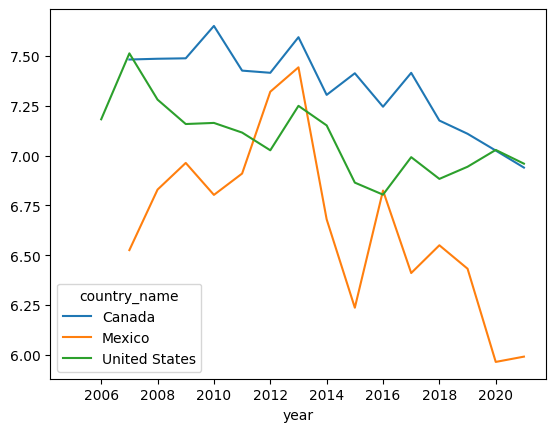

In [38]:
# Create a line chart with multiple lines
(happiness[happiness.country_name
            .isin(['Canada', 'Mexico', 'United States'])]
            .iloc[:, :3]
            .pivot(index='year', columns='country_name', values='happiness_score')
            .plot.line());